In [1]:
import pandas as pd

df = pd.read_csv('telco_customer_churn_cleaned.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [3]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [4]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


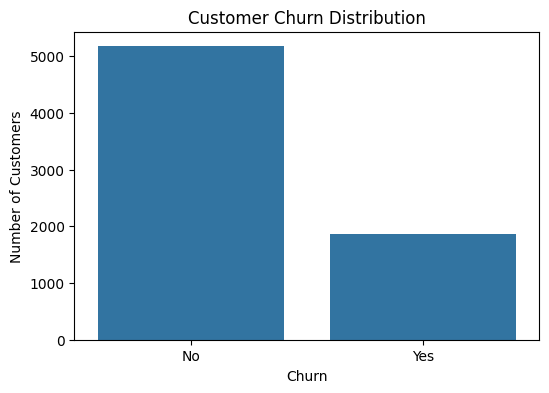

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

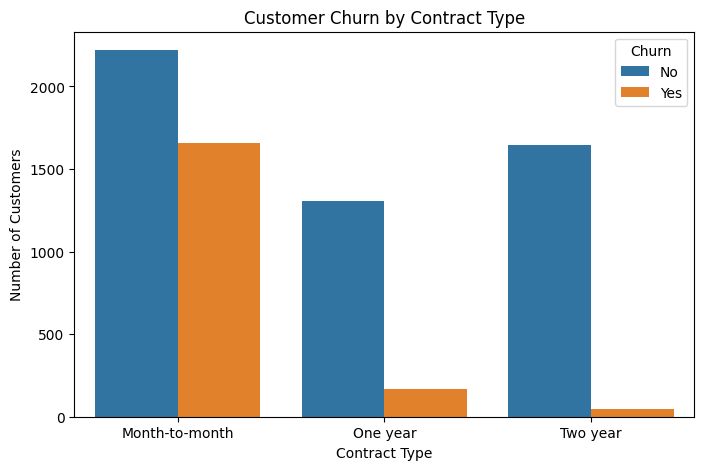

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.show()

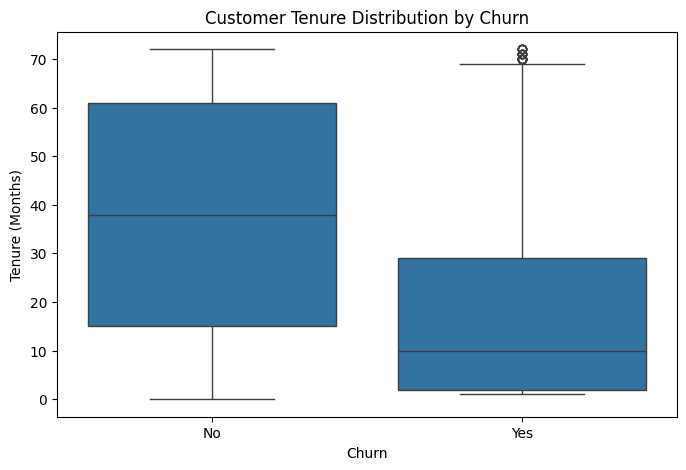

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Customer Tenure Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

In [8]:
contract_churn_rate = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


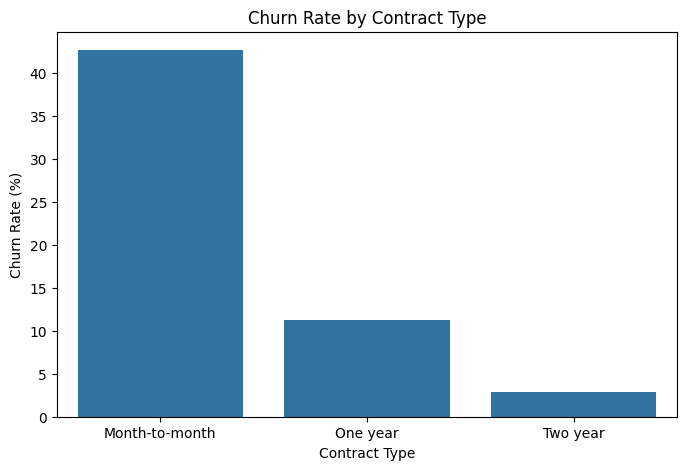

In [9]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate['Yes']
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.show()

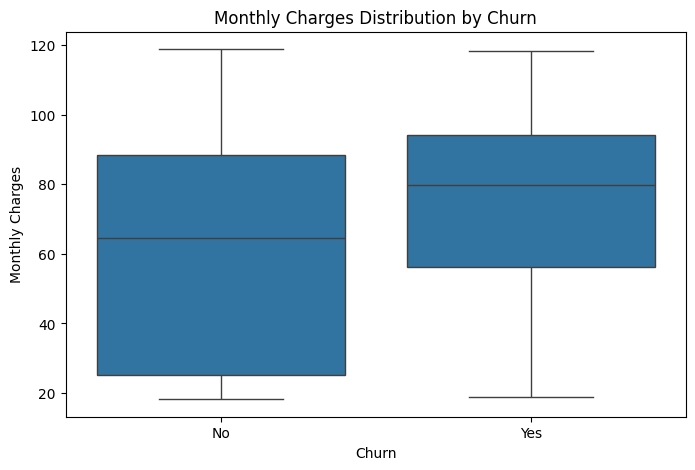

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

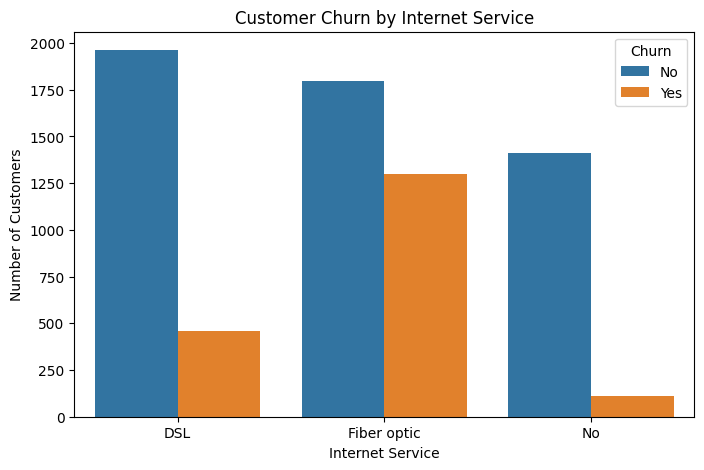

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.show()

In [12]:
internet_churn_rate = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


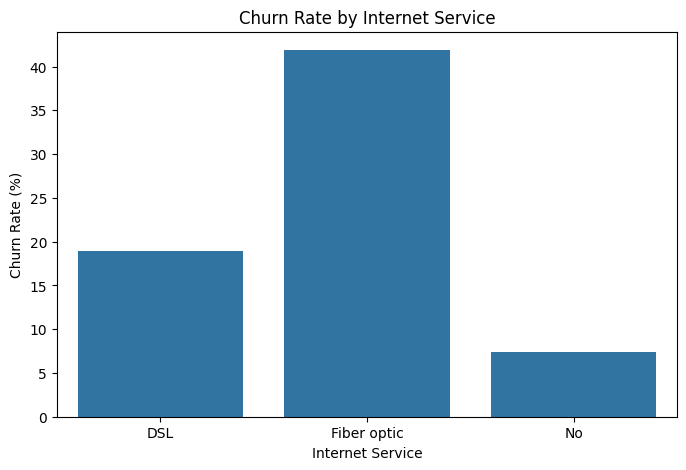

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate['Yes']
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')

plt.show()

In [14]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn']
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


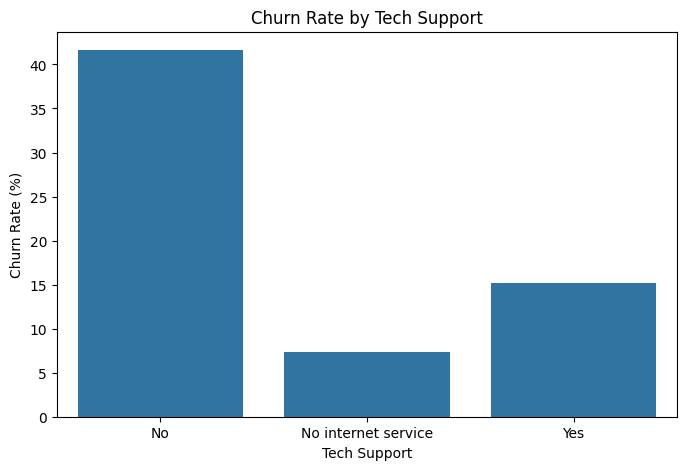

In [15]:
# Calculate churn rate within each TechSupport group
techsupport_churn_rate = pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

# Plot churn rates
plt.figure(figsize=(8, 5))

sns.barplot(
    x=techsupport_churn_rate.index,
    y=techsupport_churn_rate['Yes']
)

plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Churn Rate (%)')

plt.show()

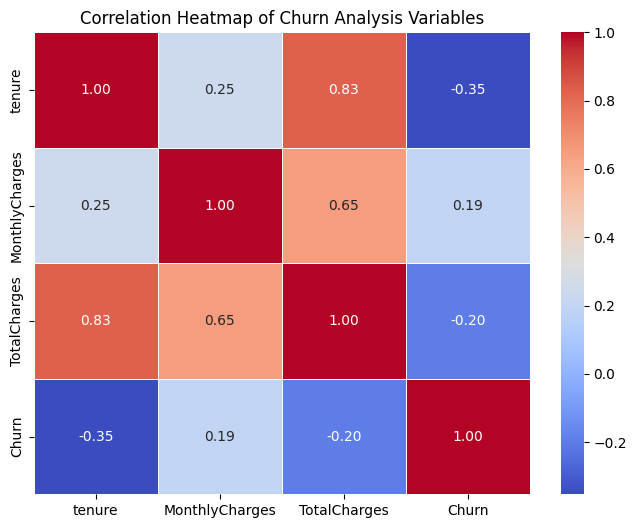

In [16]:
# Create a copy for correlation analysis
corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].copy()

# Encode Churn: No = 0, Yes = 1
corr_df['Churn'] = corr_df['Churn'].map({'No': 0, 'Yes': 1})

# Calculate correlation matrix
correlation_matrix = corr_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Churn Analysis Variables')

plt.show()

In [17]:
correlation_matrix

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn,-0.352229,0.193356,-0.198324,1.000000


## Key EDA Findings

1. **Overall Churn Distribution:** Approximately 26.54% of customers in the dataset churned, while 73.46% remained with the company.

2. **Contract Type:** Month-to-month customers show substantially more churn cases than customers with one-year or two-year contracts. Contract type therefore appears to be an important variable for further churn analysis.

3. **Tenure:** Customers who churned generally have shorter tenure than customers who stayed. The median tenure of churned customers is approximately 10 months compared with approximately 38 months for customers who stayed.

4. **Monthly Charges:** Customers who churned show a higher median monthly charge than customers who stayed, indicating an association between monthly billing levels and churn.

5. **Internet Service:** The observed churn rate varies across internet-service categories. Fiber optic customers have a churn rate of approximately 41.89%, compared with 18.96% for DSL and 7.40% for customers without internet service.

6. **Correlation Analysis:** Tenure has a moderate negative correlation with churn (-0.352), while MonthlyCharges has a weak positive correlation with churn (0.193). TotalCharges has a weak negative correlation with churn (-0.198).

7. **Tenure and TotalCharges:** Tenure and TotalCharges have a strong positive correlation (0.826), which is expected because customers who remain longer generally accumulate higher total charges.

### Overall Interpretation

The EDA indicates that customer churn is associated with several customer characteristics, particularly contract type, tenure, monthly charges, and internet service. These findings will help guide feature selection and preprocessing for the machine learning models developed in later stages of the project. The relationships identified during EDA represent associations within the dataset and should not be interpreted as causal relationships.